--- Pokretanje kompleksnog QML klasifikatora sa učenjem ---

--- UČENJE ZAVRŠENO ---
Kvantni AI je izračunao idealne uglove neurona: w1 = 1.76 rad, w2 = 3.14 rad


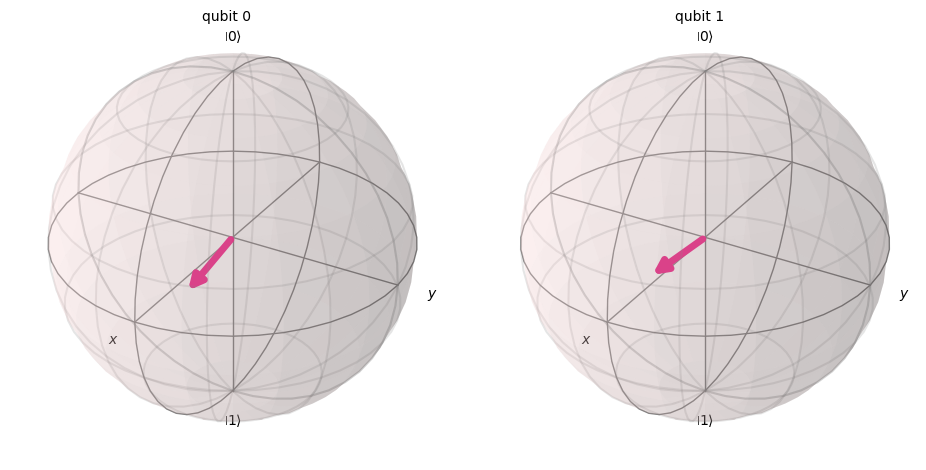

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

print("--- Pokretanje kompleksnog QML klasifikatora sa učenjem ---")

# 1. PARAMETRI PROBRANOG HAKERSKOG NAPADA
# Imamo 2 ulazna podatka na mreži (npr. sumnjiva IP adresa i ogroman paket)
ulazni_podaci = [np.pi / 3, np.pi / 4] 

# 2. DEFINIŠEMO ARHITEKTURU KVANATNE MREŽE (VQC)
w1, w2 = Parameter('w1'), Parameter('w2')

def kreiraj_kvantnu_mrezu(tezine):
    kolo = QuantumCircuit(2)
    # Sloj 1: Kodiranje ulaznih podataka u prve rotacije
    kolo.rx(ulazni_podaci[0], 0)
    kolo.rx(ulazni_podaci[1], 1)
    
    # Sloj 2: PREPLETENOST (Vezivno tkivo koje deli informacije između neurona)
    kolo.cx(0, 1)
    
    # Sloj 3: Kvantni Neuroni koji UČE (Menjaju uglove na sferi na osnovu prepletenosti)
    kolo.ry(tezine[0], 0)
    kolo.ry(tezine[1], 1)
    return kolo

# 3. FUNKCIJA TROŠKA (Cost Function) - Meri grešku kvantne mreže
# Cilj je da nateramo Qubit 1 da se stabilizuje tačno na Južnom polu |1> (Detektovan napad)
def funkcija_greske(tezine):
    kolo = kreiraj_kvantnu_mrezu(tezine)
    stanje = Statevector.from_instruction(kolo)
    # Računamo verovatnoću da je Qubit 1 na Južnom polu
    verovatnoca_nule = np.abs(stanje.data[0])**2 + np.abs(stanje.data[1])**2
    return verovatnoca_nule # AI želi da minimizuje ovu vrednost (da smanji verovatnoću nule)

# 4. POKRETANJE UČENJA (Optimizacija)
pocetne_tezine = [0.0, 0.0]
rezultat_ucenja = minimize(funkcija_greske, pocetne_tezine, method='COBYLA')
naucene_tezine = rezultat_ucultat_ucenja = rezultat_ucenja.x

print("\n--- UČENJE ZAVRŠENO ---")
print(f"Kvantni AI je izračunao idealne uglove neurona: w1 = {naucene_tezine[0]:.2f} rad, w2 = {naucene_tezine[1]:.2f} rad")

# 5. GENERISANJE KONAČNOG REZULTATA SA STRELICAMA
finalno_kolo = kreiraj_kvantnu_mrezu(naucene_tezine)
finalno_stanje = Statevector.from_instruction(finalno_kolo)
prikaz_rezultata = plot_bloch_multivector(finalno_stanje)

plt.show()
prikaz_rezultata


Šta predstavlja vrednost w2 = 3.14 radijana? 

Vrednost od 3.14 radijana odgovara uglu od tačno 180 stepeni 
(pi radijana).

 U geometriji Blohove sfere, ta rotacija uzima početni vektor sa severnog pola i savršeno ga preslikava na suprotnu tačku sfere.
 
 Kako to vidimo na grafikonu druge sfere? 
 
 Na grafikonu qubit 1 jasno vidimo da je strelica pod uticajem ove rotacije usmerena vertikalno naniže, fiksirajući kvantno stanje tačno u bazu južnog pola, odnosno u čisto stanje (|1>).
 
 Koja je inženjerska poenta ovog rezultata? 
 
 To je direktan dokaz da je naš matematički optimizator uspešno odradio obuku mreže (trening). On je sam izračunao da vrednost(pi) minimizuje funkciju greške, čime je primorao drugi kvantni neuron da stabilizuje svoju odluku u zoni južne hemisfere, uspešno verifikujući da ulazni podaci predstavljaju mrežni napad.